# Traffic Light Space

A toy space for reasoning about **how rare a valid structure is inside a space of
combinations** — the same shape of question as "which points in embedding space
decode to something meaningful?"

**The setup.** We have a palette of 50 colors (5 families × 10 shades), numbered
`1..50` reading top-left to bottom-right. A *vector* is an ordered triple

$$v = (v_\text{top},\; v_\text{middle},\; v_\text{bottom}), \qquad v_i \in \{1, \dots, 50\}$$

so the whole space is $50^3 = 125{,}000$ points — a discrete cube.

**The rule.** A vector is a valid traffic light only if *all three* slots are right:

| Slot | Must be | Shades |
|---|---|---|
| top | red | 500–700 |
| middle | yellow (amber) | 200–400 |
| bottom | green (emerald) | 300–500 |

Each slot admits exactly 3 of the 50 indices, so the valid set is a $3\times3\times3$
axis-aligned box: **27 points out of 125,000**.

The notebook builds the palette, encodes the rule, enumerates the space, and
visualizes where the valid box sits inside the cube.

## 1. The palette

In [1]:
import itertools
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

SHADES = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900]

# Families in the order they appear in the reference image, top row first.
FAMILIES: dict[str, list[str]] = {
    "gray":    ["#F9FAFB", "#F3F4F6", "#E5E7EB", "#D1D5DB", "#9CA3AF",
                "#6B7280", "#4B5563", "#374151", "#1F2937", "#111827"],
    "red":     ["#FEF2F2", "#FEE2E2", "#FECACA", "#FCA5A5", "#F87171",
                "#EF4444", "#DC2626", "#B91C1C", "#991B1B", "#7F1D1D"],
    "yellow":  ["#FFFBEB", "#FEF3C7", "#FDE68A", "#FCD34D", "#FBBF24",
                "#F59E0B", "#D97706", "#B45309", "#92400E", "#78350F"],
    "green":   ["#ECFDF5", "#D1FAE5", "#A7F3D0", "#6EE7B7", "#34D399",
                "#10B981", "#059669", "#047857", "#065F46", "#064E3B"],
    "blue":    ["#EFF6FF", "#DBEAFE", "#BFDBFE", "#93C5FD", "#60A5FA",
                "#3B82F6", "#2563EB", "#1D4ED8", "#1E40AF", "#1E3A8A"],
}

In [2]:
@dataclass(frozen=True)
class Color:
    """One palette entry, addressable by its 1-based index in the grid."""
    index: int      # 1..50, read top-left to bottom-right
    family: str     # "red", "yellow", ...
    shade: int      # 50..900
    hex: str

    @property
    def name(self) -> str:
        return f"{self.family}-{self.shade}"


PALETTE: list[Color] = [
    Color(index=row * len(SHADES) + col + 1, family=family, shade=shade, hex=hexcode)
    for row, (family, hexes) in enumerate(FAMILIES.items())
    for col, (shade, hexcode) in enumerate(zip(SHADES, hexes))
]

N_COLORS = len(PALETTE)
BY_INDEX = {c.index: c for c in PALETTE}
BY_NAME = {c.name: c for c in PALETTE}


def index_of(family: str, shade: int) -> int:
    """Palette index (1-based) of a family/shade pair, e.g. index_of('red', 500) -> 16."""
    return BY_NAME[f"{family}-{shade}"].index


assert N_COLORS == 50
assert index_of("gray", 50) == 1 and index_of("blue", 900) == 50
assert index_of("red", 500) == 16 and index_of("green", 300) == 34
print(f"{N_COLORS} colors, indices 1..{N_COLORS}")
print("index 16 ->", BY_INDEX[16].name, BY_INDEX[16].hex)

50 colors, indices 1..50
index 16 -> red-500 #EF4444


The reference grid, with the index each swatch carries in the rest of the notebook.
Reading order is left-to-right, top-to-bottom, so each family owns a contiguous
run of ten indices: gray `1–10`, red `11–20`, yellow `21–30`, green `31–40`,
blue `41–50`.

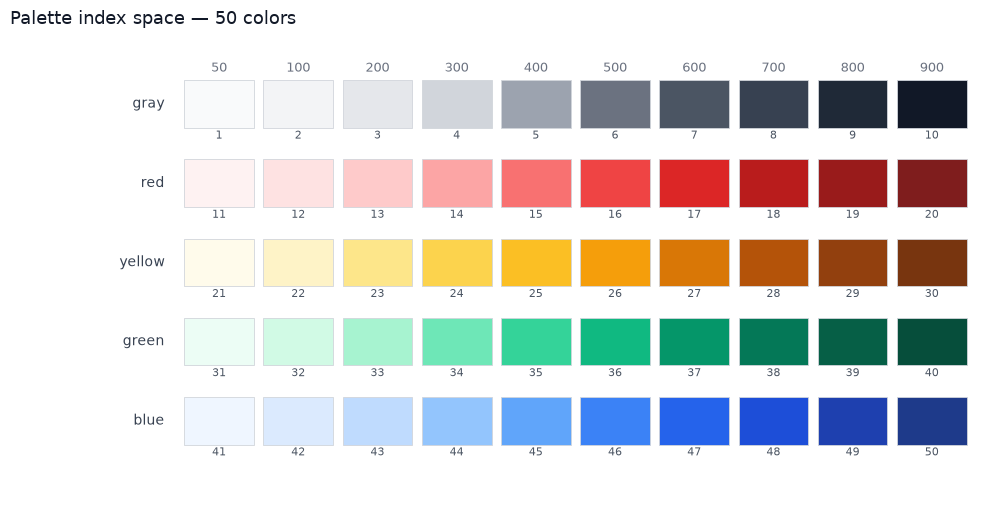

In [3]:
def draw_palette(ax: plt.Axes, highlight: set[int] | None = None) -> None:
    """Render the 5x10 palette grid; optionally ring a subset of indices."""
    highlight = highlight or set()
    for c in PALETTE:
        row, col = divmod(c.index - 1, len(SHADES))
        selected = c.index in highlight
        ax.add_patch(Rectangle(
            (col, -row), 0.88, 0.60, facecolor=c.hex,
            edgecolor="#111827" if selected else "#D1D5DB",
            linewidth=2.0 if selected else 0.6,
        ))
        ax.text(col + 0.44, -row - 0.03, str(c.index), ha="center", va="top",
                fontsize=8, color="#4B5563",
                fontweight="bold" if selected else "normal")

    for row, family in enumerate(FAMILIES):
        ax.text(-0.25, -row + 0.30, family, ha="right", va="center",
                fontsize=10, color="#374151")
    for col, shade in enumerate(SHADES):
        ax.text(col + 0.44, 0.75, str(shade), ha="center", va="center",
                fontsize=9, color="#6B7280")

    ax.set_xlim(-2.2, len(SHADES))
    ax.set_ylim(-len(FAMILIES) + 0.3, 1.1)
    ax.set_aspect("equal")
    ax.axis("off")


fig, ax = plt.subplots(figsize=(11, 5.2), facecolor="white")
draw_palette(ax)
ax.set_title("Palette index space — 50 colors", loc="left", fontsize=13, color="#111827", pad=12)
fig.tight_layout()
plt.show()

## 2. The rule

One valid band per slot. Everything about validity lives in `RULES`; the rest of
the notebook only reads it, so changing a band changes every count and figure below.

In [4]:
@dataclass(frozen=True)
class SlotRule:
    """The colors one position of the triple will accept."""
    slot: str        # "top" / "middle" / "bottom"
    family: str
    shades: tuple[int, ...]

    @property
    def indices(self) -> tuple[int, ...]:
        return tuple(index_of(self.family, s) for s in self.shades)


RULES: tuple[SlotRule, ...] = (
    SlotRule("top",    "red",    (500, 600, 700)),
    SlotRule("middle", "yellow", (200, 300, 400)),
    SlotRule("bottom", "green",  (300, 400, 500)),
)

VALID_INDICES: tuple[tuple[int, ...], ...] = tuple(r.indices for r in RULES)

for rule, idx in zip(RULES, VALID_INDICES):
    band = ", ".join(f"{rule.family}-{s} (#{i})" for s, i in zip(rule.shades, idx))
    print(f"{rule.slot:<7} {band}")

top     red-500 (#16), red-600 (#17), red-700 (#18)
middle  yellow-200 (#23), yellow-300 (#24), yellow-400 (#25)
bottom  green-300 (#34), green-400 (#35), green-500 (#36)


In [5]:
def is_valid(vector: tuple[int, int, int]) -> bool:
    """True iff every slot of the triple falls in its allowed band."""
    return all(v in allowed for v, allowed in zip(vector, VALID_INDICES))


assert is_valid((16, 23, 34))          # red-500, yellow-200, green-300
assert not is_valid((16, 23, 33))      # green-200 is one shade too light
assert not is_valid((15, 23, 34))      # red-400 is one shade too light
assert not is_valid((34, 23, 16))      # right colors, wrong order
print("valid  (16, 23, 34):", is_valid((16, 23, 34)))
print("invalid(34, 23, 16):", is_valid((34, 23, 16)))

valid  (16, 23, 34): True
invalid(34, 23, 16): False


## 3. Enumerating the space

125,000 triples is small enough to enumerate exhaustively — no sampling, no
estimation. We keep the full space as an `(N, 3)` integer array and a boolean mask.

In [6]:
SPACE = np.array(list(itertools.product(range(1, N_COLORS + 1), repeat=3)), dtype=np.int16)

# A triple is valid iff each column lands in that slot's band -> AND of three membership tests.
valid_mask = np.logical_and.reduce([
    np.isin(SPACE[:, slot], allowed) for slot, allowed in enumerate(VALID_INDICES)
])

VALID = SPACE[valid_mask]
INVALID = SPACE[~valid_mask]

total, n_valid = len(SPACE), len(VALID)
density = n_valid / total

assert total == N_COLORS ** 3 == 125_000
assert n_valid == np.prod([len(i) for i in VALID_INDICES]) == 27
assert all(is_valid(tuple(v)) for v in VALID)

print(f"total vectors : {total:,}")
print(f"valid         : {n_valid:,}")
print(f"invalid       : {len(INVALID):,}")
print(f"density       : {density:.5%}  (1 in {round(1 / density):,})")

total vectors : 125,000
valid         : 27
invalid       : 124,973
density       : 0.02160%  (1 in 4,630)


27 in 125,000 — about **1 in 4,630**. Worth noting *why* it is that small: the
three constraints are independent, so the densities multiply. Each slot alone
accepts 3/50 = 6%, which is not rare at all; three of them in a row is.

In [7]:
per_slot = [len(a) / N_COLORS for a in VALID_INDICES]
print("per-slot pass rate :", "  ".join(f"{p:.0%}" for p in per_slot))
print("product            :", f"{np.prod(per_slot):.5%}")

# How much does each constraint buy you? Drop one at a time.
for dropped in range(3):
    kept = [np.isin(SPACE[:, s], VALID_INDICES[s]) for s in range(3) if s != dropped]
    n = int(np.logical_and.reduce(kept).sum())
    print(f"ignoring the {RULES[dropped].slot:<6} constraint -> {n:>6,} vectors pass "
          f"({n / total:.2%})")

per-slot pass rate : 6%  6%  6%
product            : 0.02160%
ignoring the top    constraint ->    450 vectors pass (0.36%)
ignoring the middle constraint ->    450 vectors pass (0.36%)
ignoring the bottom constraint ->    450 vectors pass (0.36%)


## 4. Where the valid band sits, one slot at a time

Before the 3D view, the marginals: for each slot, which of the 50 indices are
admissible. Three narrow windows, each inside a different family.

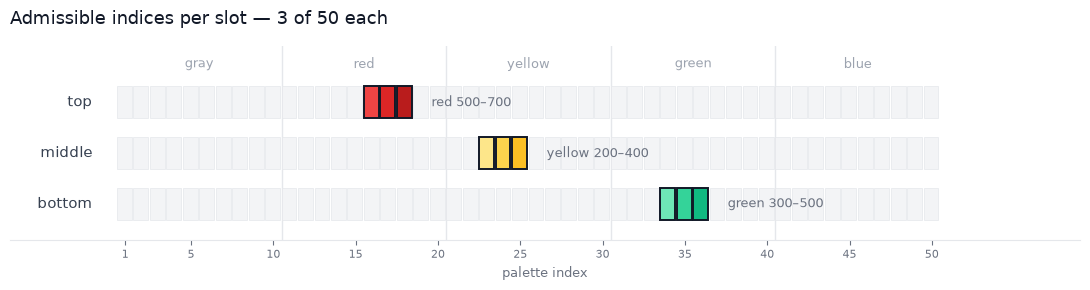

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.0), facecolor="white")

for row, (rule, allowed) in enumerate(zip(RULES, VALID_INDICES)):
    y = -row
    for c in PALETTE:
        ok = c.index in allowed
        ax.add_patch(Rectangle(
            (c.index - 0.5, y - 0.32), 0.9, 0.64,
            facecolor=c.hex if ok else "#F3F4F6",
            edgecolor="#111827" if ok else "#E5E7EB",
            linewidth=1.4 if ok else 0.5,
        ))
    ax.text(-1.0, y, rule.slot, ha="right", va="center", fontsize=11, color="#374151")
    ax.text(allowed[-1] + 1.6, y, f"{rule.family} {rule.shades[0]}–{rule.shades[-1]}",
            ha="left", va="center", fontsize=9, color="#6B7280")

# Family boundaries every 10 indices.
for boundary in range(10, N_COLORS, 10):
    ax.axvline(boundary + 0.5, color="#E5E7EB", linewidth=1, zorder=0)
for row, family in enumerate(FAMILIES):
    ax.text(row * 10 + 5.5, 0.75, family, ha="center", va="center", fontsize=9, color="#9CA3AF")

ax.set_xlim(-6, N_COLORS + 9)
ax.set_ylim(-2.7, 1.1)
ax.set_xticks([1] + list(range(5, N_COLORS + 1, 5)))
ax.tick_params(axis="x", colors="#6B7280", labelsize=8)
ax.set_yticks([])
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#E5E7EB")
ax.set_xlabel("palette index", fontsize=9, color="#6B7280")
ax.set_title("Admissible indices per slot — 3 of 50 each", loc="left",
             fontsize=13, color="#111827", pad=16)
fig.tight_layout()
plt.show()

## 5. The space in 3D

Each axis is one slot of the triple, running over the full palette index `1..50`.
The cloud is a random sample of the invalid space (drawing all 125,000 points
would be a solid gray block); the valid set is the small dark box near the front.
Each valid point is drawn in its own **top** color, which is why the box reads red.

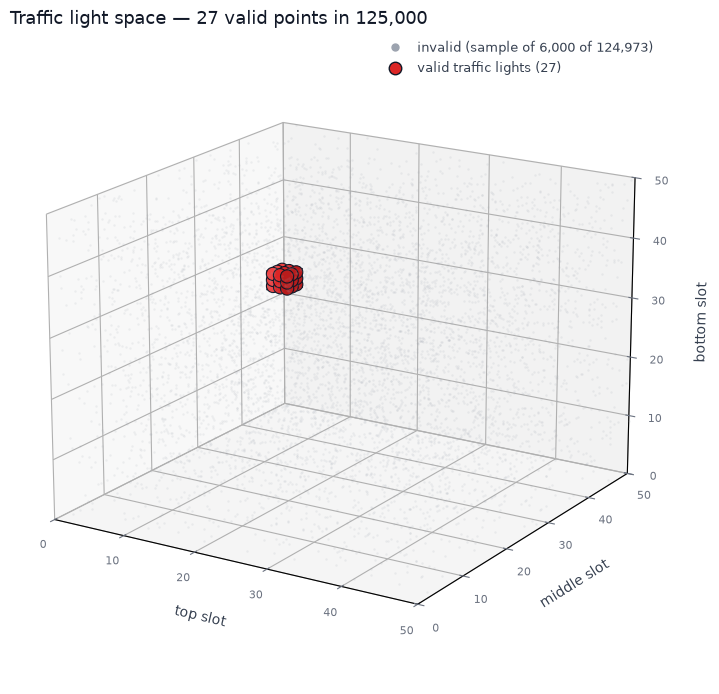

In [9]:
def cuboid_edges(lo: np.ndarray, hi: np.ndarray) -> list[np.ndarray]:
    """The 12 edges of an axis-aligned box, as (2, 3) segments."""
    corners = np.array(list(itertools.product(*zip(lo, hi))), dtype=float)
    return [np.stack([a, b]) for a, b in itertools.combinations(corners, 2)
            if np.isclose(a, b).sum() == 2]  # neighbours differ on exactly one axis


rng = np.random.default_rng(0)
sample = INVALID[rng.choice(len(INVALID), size=6000, replace=False)]

fig = plt.figure(figsize=(9.5, 8.5), facecolor="white")
ax = fig.add_subplot(projection="3d")
ax.set_facecolor("white")

ax.scatter(*sample.T, s=3, c="#9CA3AF", alpha=0.14, linewidths=0, depthshade=False)

lo = np.array([min(a) for a in VALID_INDICES]) - 0.5
hi = np.array([max(a) for a in VALID_INDICES]) + 0.5
for edge in cuboid_edges(lo, hi):
    ax.plot(*edge.T, color="#111827", linewidth=1.2, alpha=0.55)

ax.scatter(*VALID.T, s=90, c=[BY_INDEX[v].hex for v in VALID[:, 0]],
           edgecolors="#111827", linewidths=0.8, depthshade=False,
           label=f"valid traffic lights ({n_valid})")

ax.set_xlabel("top slot", labelpad=10, color="#374151")
ax.set_ylabel("middle slot", labelpad=10, color="#374151")
ax.set_zlabel("bottom slot", labelpad=10, color="#374151")
for axis_set in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
    axis_set(1, N_COLORS)
ax.set_xticks(range(0, 51, 10)); ax.set_yticks(range(0, 51, 10)); ax.set_zticks(range(0, 51, 10))
ax.tick_params(colors="#6B7280", labelsize=8)
ax.view_init(elev=18, azim=-58)
ax.set_title(f"Traffic light space — {n_valid} valid points in {total:,}",
             loc="left", fontsize=13, color="#111827", pad=4)
# Proxy handles: the real invalid marks are far too faint to read in a legend.
handles = [
    plt.Line2D([], [], marker="o", linestyle="none", markersize=5,
               color="#9CA3AF", label=f"invalid (sample of 6,000 of {len(INVALID):,})"),
    plt.Line2D([], [], marker="o", linestyle="none", markersize=9, color="#DC2626",
               markeredgecolor="#111827", label=f"valid traffic lights ({n_valid})"),
]
ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=9, labelcolor="#374151")
plt.show()

any red / any yellow / any green :  1,000  (0.80% of the cube)
the specified shades             :     27  (0.0216% of the cube, 2.7% of the family region)


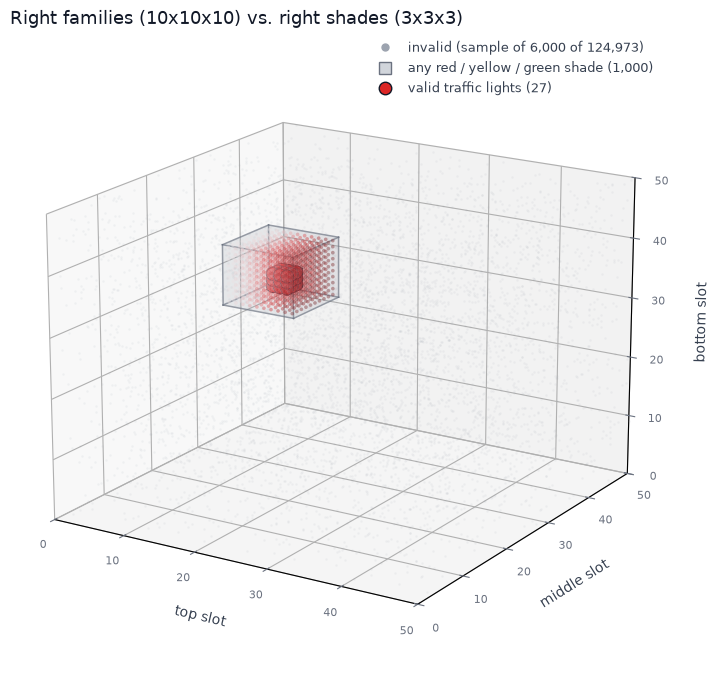

In [10]:
# Two nested regions: "the right three families, any shade" and, inside it,
# "the exact shades the rule asks for".
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

FAMILY_INDICES = tuple(tuple(index_of(r.family, s) for s in SHADES) for r in RULES)

family_mask = np.logical_and.reduce([
    np.isin(SPACE[:, slot], allowed) for slot, allowed in enumerate(FAMILY_INDICES)
])
FAMILY = SPACE[family_mask]

assert np.all(family_mask[valid_mask])          # every traffic light is red/yellow/green
print(f"any red / any yellow / any green : {len(FAMILY):>6,}  ({len(FAMILY) / total:.2%} of the cube)")
print(f"the specified shades             : {n_valid:>6,}  ({n_valid / total:.4%} of the cube,"
      f" {n_valid / len(FAMILY):.1%} of the family region)")


def cuboid_faces(lo: np.ndarray, hi: np.ndarray) -> list[np.ndarray]:
    """The 6 faces of an axis-aligned box, as (4, 3) polygons."""
    faces = []
    for axis in range(3):
        others = [a for a in range(3) if a != axis]
        for value in (lo[axis], hi[axis]):
            square = np.empty((4, 3))
            square[:, axis] = value
            square[:, others] = [[lo[others[0]], lo[others[1]]], [hi[others[0]], lo[others[1]]],
                                 [hi[others[0]], hi[others[1]]], [lo[others[0]], hi[others[1]]]]
            faces.append(square)
    return faces


def draw_box(ax, allowed, face: str, edge: str, alpha: float) -> None:
    lo = np.array([min(a) for a in allowed]) - 0.5
    hi = np.array([max(a) for a in allowed]) + 0.5
    ax.add_collection3d(Poly3DCollection(cuboid_faces(lo, hi), facecolors=face,
                                         alpha=alpha, edgecolors="none", zorder=1))
    for edge_segment in cuboid_edges(lo, hi):
        ax.plot(*edge_segment.T, color=edge, linewidth=1.1, alpha=0.7, zorder=2)


fig = plt.figure(figsize=(9.5, 8.5), facecolor="white")
ax = fig.add_subplot(projection="3d")
ax.set_facecolor("white")

ax.scatter(*sample.T, s=3, c="#9CA3AF", alpha=0.10, linewidths=0, depthshade=False)

draw_box(ax, FAMILY_INDICES, face="#9CA3AF", edge="#6B7280", alpha=0.10)
ax.scatter(*FAMILY.T, s=7, c=[BY_INDEX[v].hex for v in FAMILY[:, 0]],
           alpha=0.45, linewidths=0, depthshade=False)

draw_box(ax, VALID_INDICES, face="#111827", edge="#111827", alpha=0.08)
ax.scatter(*VALID.T, s=90, c=[BY_INDEX[v].hex for v in VALID[:, 0]],
           edgecolors="#111827", linewidths=0.8, depthshade=False)

handles = [
    plt.Line2D([], [], marker="o", linestyle="none", markersize=5, color="#9CA3AF",
               label=f"invalid (sample of 6,000 of {len(INVALID):,})"),
    plt.Line2D([], [], marker="s", linestyle="none", markersize=9, color="#D1D5DB",
               markeredgecolor="#6B7280",
               label=f"any red / yellow / green shade ({len(FAMILY):,})"),
    plt.Line2D([], [], marker="o", linestyle="none", markersize=9, color="#DC2626",
               markeredgecolor="#111827", label=f"valid traffic lights ({n_valid})"),
]
ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=9, labelcolor="#374151")

ax.set_xlabel("top slot", labelpad=10, color="#374151")
ax.set_ylabel("middle slot", labelpad=10, color="#374151")
ax.set_zlabel("bottom slot", labelpad=10, color="#374151")
for axis_set in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
    axis_set(1, N_COLORS)
ax.set_xticks(range(0, 51, 10)); ax.set_yticks(range(0, 51, 10)); ax.set_zticks(range(0, 51, 10))
ax.tick_params(colors="#6B7280", labelsize=8)
ax.view_init(elev=18, azim=-58)
ax.set_title("Right families (10x10x10) vs. right shades (3x3x3)",
             loc="left", fontsize=13, color="#111827", pad=4)
plt.show()

The 3D view is honest about the scale but hard to read precisely, so here are the
three axis-aligned projections. Each shows a pair of slots; the shaded band is
where that pair is jointly valid. Only their **intersection** in all three
projections — the 27 points — is a traffic light.

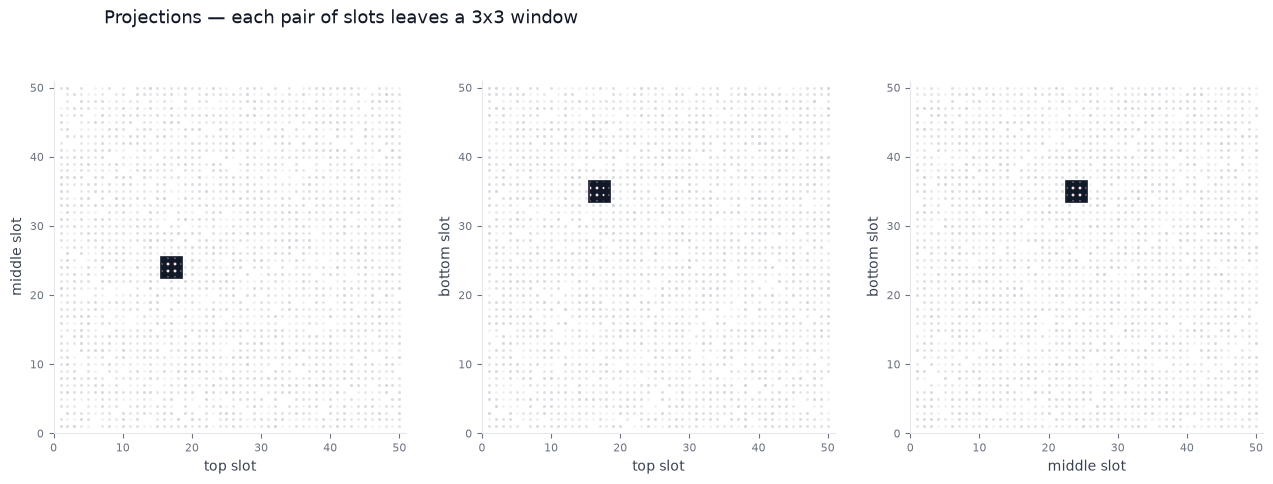

In [11]:
pairs = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), facecolor="white")

for ax, (a, b) in zip(axes, pairs):
    ax.scatter(sample[:, a], sample[:, b], s=4, c="#D1D5DB", alpha=0.35, linewidths=0)
    ax.add_patch(Rectangle(
        (min(VALID_INDICES[a]) - 0.5, min(VALID_INDICES[b]) - 0.5),
        len(VALID_INDICES[a]), len(VALID_INDICES[b]),
        facecolor="#FEE2E2", edgecolor="#111827", linewidth=1.2, zorder=3,
    ))
    ax.scatter(VALID[:, a], VALID[:, b], s=16, c="#111827", zorder=4)

    ax.set_xlabel(f"{RULES[a].slot} slot", fontsize=10, color="#374151")
    ax.set_ylabel(f"{RULES[b].slot} slot", fontsize=10, color="#374151")
    ax.set_xlim(0, N_COLORS + 1); ax.set_ylim(0, N_COLORS + 1)
    ax.set_aspect("equal")
    ax.tick_params(colors="#6B7280", labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#E5E7EB")

fig.suptitle("Projections — each pair of slots leaves a 3x3 window",
             x=0.09, ha="left", fontsize=13, color="#111827")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## 6. The 27 valid traffic lights

The entire valid set, drawn as the thing it encodes.

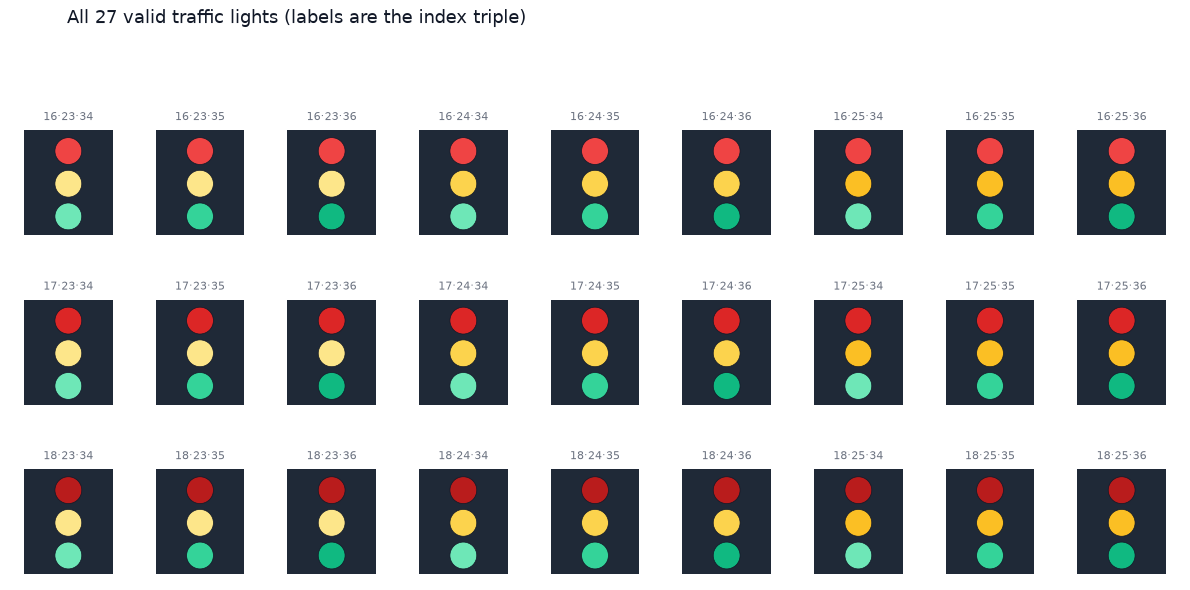

In [12]:
fig, axes = plt.subplots(3, 9, figsize=(12, 6.4), facecolor="white")

for ax, vector in zip(axes.ravel(), VALID):
    ax.add_patch(Rectangle((0.12, 0.05), 0.76, 0.90, facecolor="#1F2937",
                           edgecolor="none", zorder=1))
    for lamp, index in enumerate(vector):
        ax.add_patch(plt.Circle((0.5, 0.77 - lamp * 0.28), 0.115,
                                facecolor=BY_INDEX[index].hex, edgecolor="#111827",
                                linewidth=0.5, zorder=2))
    ax.set_title("·".join(str(v) for v in vector), fontsize=8, color="#6B7280", pad=3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle(f"All {n_valid} valid traffic lights (labels are the index triple)",
             x=0.06, ha="left", fontsize=13, color="#111827")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Takeaway

The valid set is a $3\times3\times3$ box: a **Cartesian product** of three
independent per-slot bands, not an arbitrary scatter of good points. Two
consequences worth carrying into harder spaces:

- **Validity is conjunctive, so density is multiplicative.** Each slot alone is
  6% permissive; all three together are 0.02%. Loosening any single constraint
  multiplies the valid count by ~16.7× (see §3) — rarity here is a property of the
  *conjunction*, not of any one rule being strict.
- **The valid region is connected and axis-aligned.** From any traffic light you
  can reach any other by changing one slot at a time, never leaving validity —
  so local search works. That is the friendly case; a valid set that was scattered
  or curved would not give you that, and gradient/nearest-neighbour moves through
  it would keep falling out of the region.

To change the world, edit `RULES` in §2 and re-run — every count, projection, and
figure follows from it.